In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# Cell 1: Load the raw merged dataset

file_path = '../../data/raw/smart_travel_dataset.csv' 

# Load the dataframe
df = pd.read_csv(file_path)

# Quick sanity check: Verify we have exactly 108 rows and check the exact column names
print(f"Dataset shape: {df.shape}")
print("\nColumns available for feature engineering:")
print(df.columns.tolist())

# Display the first few rows to verify the data looks correct
display(df.head())

Dataset shape: (108, 16)

Columns available for feature engineering:
['city', 'country', 'lat', 'lng', 'population', 'Cost of Living Index', 'Rent Index', 'Cost of Living Plus Rent Index', 'Groceries Index', 'Restaurant Price Index', 'Local Purchasing Power Index', 'Temp_DecJanFeb', 'Temp_MarAprMay', 'Temp_JunJulAug', 'Temp_SepOctNov', 'Temp_YearAvg']


,city,country,lat,lng,population,Cost of Living Index,Rent Index,Cost of Living Plus Rent Index,Groceries Index,Restaurant Price Index,Local Purchasing Power Index,Temp_DecJanFeb,Temp_MarAprMay,Temp_JunJulAug,Temp_SepOctNov,Temp_YearAvg
0,Tokyo,Japan,35.6870,139.7495,37785000.0,85.61,42.71,65.50,94.94,52.26,88.58,6.2,13.6,24.3,17.5,15.4
1,Jakarta,Indonesia,-6.1750,106.8275,33756000.0,40.86,16.46,29.42,41.78,23.44,25.32,26.2,26.9,26.6,27.1,26.7
2,Guangzhou,China,23.1300,113.2600,26940000.0,41.11,21.43,31.88,43.52,27.08,70.13,14.9,22.1,28.5,24.1,22.4
3,Mumbai,India,19.0761,72.8775,24973000.0,29.33,19.72,24.82,29.73,25.17,48.03,24.5,28.4,28.0,27.6,27.1
4,Manila,Philippines,14.5958,120.9772,24922000.0,40.77,25.18,33.46,39.85,25.18,22.24,27.0,29.6,28.7,28.3,28.4


In [3]:
# Cell 2: Feature Engineering

# 1. Climate Features
# Define the seasonal columns to find the max and min temperatures across the year
seasonal_cols = ['Temp_DecJanFeb', 'Temp_MarAprMay', 'Temp_JunJulAug', 'Temp_SepOctNov']
df['Temp_Variance'] = df[seasonal_cols].max(axis=1) - df[seasonal_cols].min(axis=1)

# 2. Economic Features
# Average the general cost of living with restaurant prices (ignoring rent)
df['Tourist_Cost_Score'] = (df['Cost of Living Index'] + df['Restaurant Price Index']) / 2

# Ratio of eating out vs buying groceries. 
df['Dining_Out_Premium'] = df['Restaurant Price Index'] / df['Groceries Index']

# 3. Demographic Features
# Convert raw population into categorical bins
# Bins: 0 to 3M (Mid/Small), 3M to 10M (Large), 10M to 100M (Megacity)
bins = [0, 3000000, 10000000, 100000000]
labels = ['Mid/Small', 'Large', 'Megacity']
df['City_Scale'] = pd.cut(df['population'], bins=bins, labels=labels)

# 4. Cleanup
# Drop the columns that are just noise for tourists
cols_to_drop = ['Rent Index', 'Cost of Living Plus Rent Index', 'population']
df = df.drop(columns=cols_to_drop)

# Verify the changes
print("Shape after engineering:", df.shape)
display(df[['city', 'Temp_Variance', 'Tourist_Cost_Score', 'Dining_Out_Premium', 'City_Scale']].head())

Shape after engineering: (108, 17)


,city,Temp_Variance,Tourist_Cost_Score,Dining_Out_Premium,City_Scale
0,Tokyo,18.1,68.935,0.550453,Megacity
1,Jakarta,0.9,32.150,0.561034,Megacity
2,Guangzhou,13.6,34.095,0.622243,Megacity
3,Mumbai,3.9,27.250,0.846620,Megacity
4,Manila,2.6,32.975,0.631870,Megacity


In [5]:
# Cell 3: Auto-Labeling the Target Variable (Travel_Style) - TWEAKED

def assign_travel_style(row):
    # 1. Culture (Moved to Top): Catch massive hubs first so they don't get swallowed by Budget/Luxury
    if row['City_Scale'] == 'Megacity':
        return 'Culture'
        
    # 2. Relaxation (Broadened): Looser climate rules for warm, relatively stable destinations
    elif row['Temp_Variance'] <= 12 and row['Temp_YearAvg'] >= 22:
        return 'Relaxation'
        
    # 3. Luxury (Slightly Lowered): Capture upper-tier expensive cities
    elif row['Tourist_Cost_Score'] >= 70:
        return 'Luxury'
        
    # 4. Family (Slightly Lowered): High purchasing power (safety/infrastructure)
    elif row['Local Purchasing Power Index'] >= 65:
        return 'Family'
        
    # 5. Budget (Shrunken and Moved Down): Only catches genuinely low-cost places
    elif row['Tourist_Cost_Score'] <= 32:
        return 'Budget'
        
    # 6. Adventure: Fallback for everything else (usually places with distinct seasons or mid-tier costs)
    else:
        return 'Adventure'

# Apply the updated function
df['Travel_Style'] = df.apply(assign_travel_style, axis=1)

# Check the new distribution
print("NEW Class Distribution:\n")
print(df['Travel_Style'].value_counts())
print(f"\nTotal Labeled: {df['Travel_Style'].count()} / 108")

NEW Class Distribution:

Travel_Style
Culture       26
Adventure     18
Family        17
Relaxation    16
Luxury        16
Budget        15
Name: count, dtype: int64

Total Labeled: 108 / 108


In [6]:
# Cell 4: Final Validation

print("--- Data Info ---")
df.info()

print("\n--- Missing Values Check ---")
# This will sum up any nulls. We want to see all zeros.
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0] if missing_values.any() else "Perfect! No missing values found.")

print("\n--- Quick Look at Data Types ---")
# Ensuring our indices and temperatures are floats/ints, not strings
print(df.dtypes)

--- Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype   
---  ------                        --------------  -----   
 0   city                          108 non-null    str     
 1   country                       108 non-null    str     
 2   lat                           108 non-null    float64 
 3   lng                           108 non-null    float64 
 4   Cost of Living Index          108 non-null    float64 
 5   Groceries Index               108 non-null    float64 
 6   Restaurant Price Index        108 non-null    float64 
 7   Local Purchasing Power Index  108 non-null    float64 
 8   Temp_DecJanFeb                108 non-null    float64 
 9   Temp_MarAprMay                108 non-null    float64 
 10  Temp_JunJulAug                108 non-null    float64 
 11  Temp_SepOctNov                108 non-null    float64 
 12  Temp_YearAvg                  108 non-null 

In [7]:
import os
from pathlib import Path

# Cell 5: Directory Setup
# Since the notebook is in notebook/cleaning/, we go up two levels to the root, then into graph/EDA/
eda_dir = Path('../../graph/EDA').resolve()

# Create the directory (and any necessary parent directories)
eda_dir.mkdir(parents=True, exist_ok=True)

print(f"EDA graph directory ready at: {eda_dir}")
# We will use this 'eda_dir' variable in the next cells to save our plots!

EDA graph directory ready at: /home/bmislol/VSCode/smart-travel-planner/graph/EDA


Successfully saved distribution bar chart to: /home/bmislol/VSCode/smart-travel-planner/graph/EDA/class_distribution.png


/tmp/ipykernel_426552/4201538828.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=style_counts.index, y=style_counts.values, ax=ax, palette='viridis')


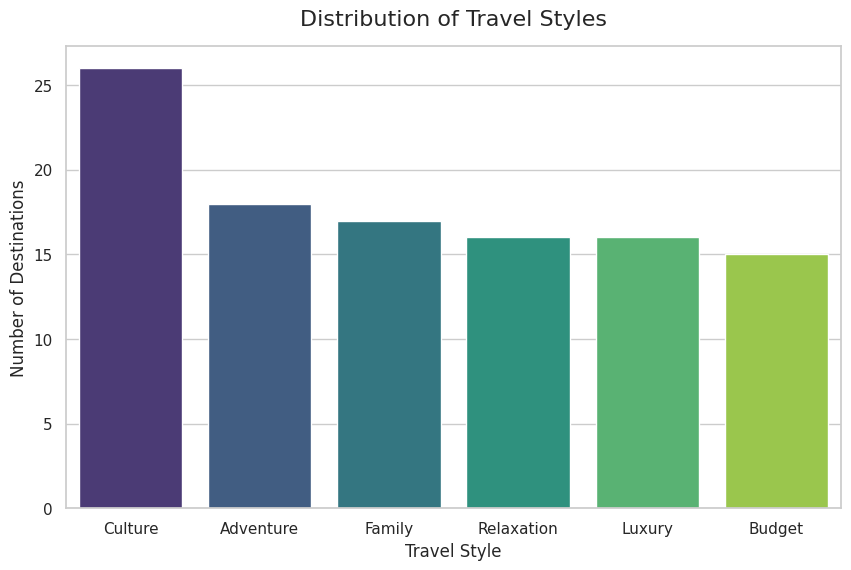

In [8]:
# Cell 6: Class Distribution Bar Chart
fig, ax = plt.subplots(figsize=(10, 6))

# Get the counts for each category
style_counts = df['Travel_Style'].value_counts()

# Create a colorful bar chart
sns.barplot(x=style_counts.index, y=style_counts.values, ax=ax, palette='viridis')

# Add labels and title
ax.set_title('Distribution of Travel Styles', fontsize=16, pad=15)
ax.set_xlabel('Travel Style', fontsize=12)
ax.set_ylabel('Number of Destinations', fontsize=12)

# Save the plot to the dynamic directory
dist_plot_path = eda_dir / 'class_distribution.png'
plt.savefig(dist_plot_path, bbox_inches='tight')

print(f"Successfully saved distribution bar chart to: {dist_plot_path}")

Successfully saved correlation heatmap to: /home/bmislol/VSCode/smart-travel-planner/graph/EDA/correlation_heatmap.png


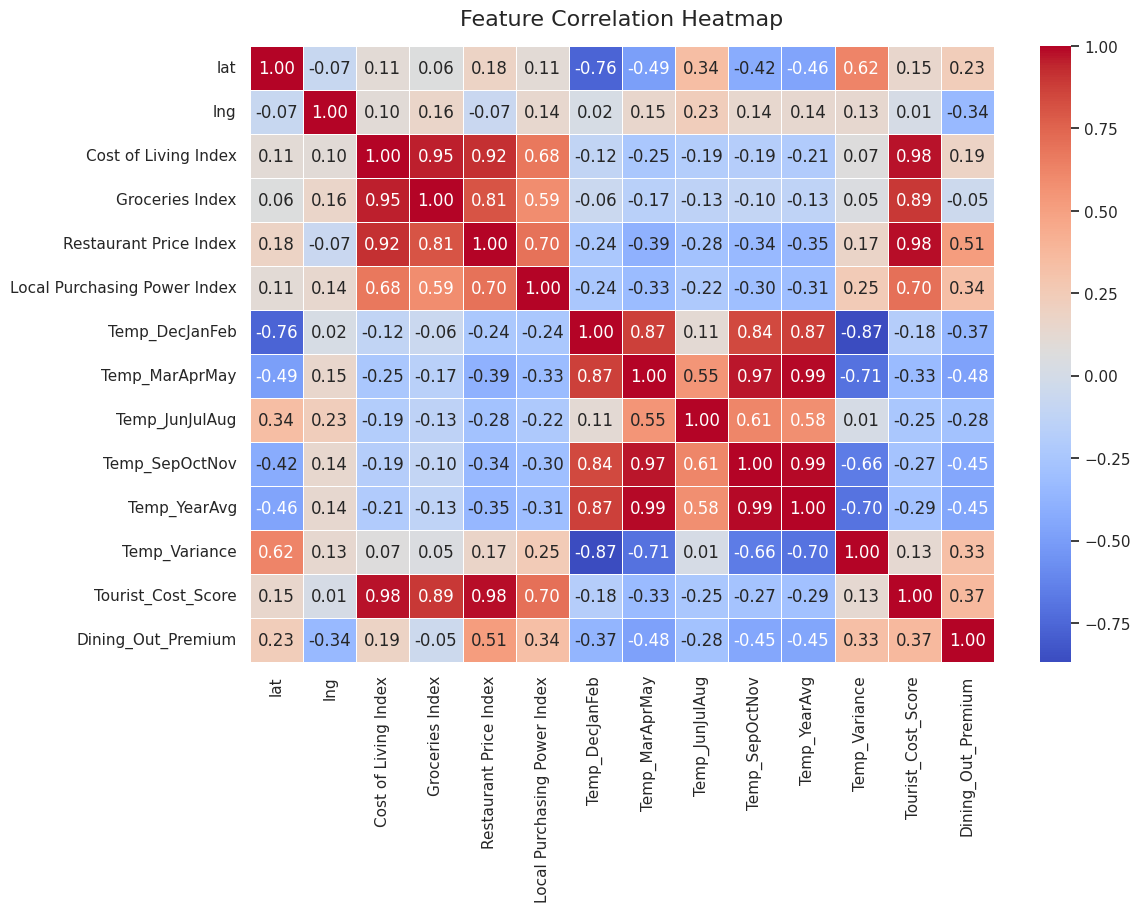

In [9]:
# Cell 7: Correlation Heatmap
fig, ax = plt.subplots(figsize=(12, 8))

# Select only the numeric columns for correlation
numeric_cols = df.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix
corr_matrix = numeric_cols.corr()

# Create a heatmap using seaborn
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, ax=ax)

# Add title
ax.set_title('Feature Correlation Heatmap', fontsize=16, pad=15)

# Save the plot
heat_plot_path = eda_dir / 'correlation_heatmap.png'
plt.savefig(heat_plot_path, bbox_inches='tight')

print(f"Successfully saved correlation heatmap to: {heat_plot_path}")

Successfully saved feature scatter plot to: /home/bmislol/VSCode/smart-travel-planner/graph/EDA/feature_scatter_plot.png


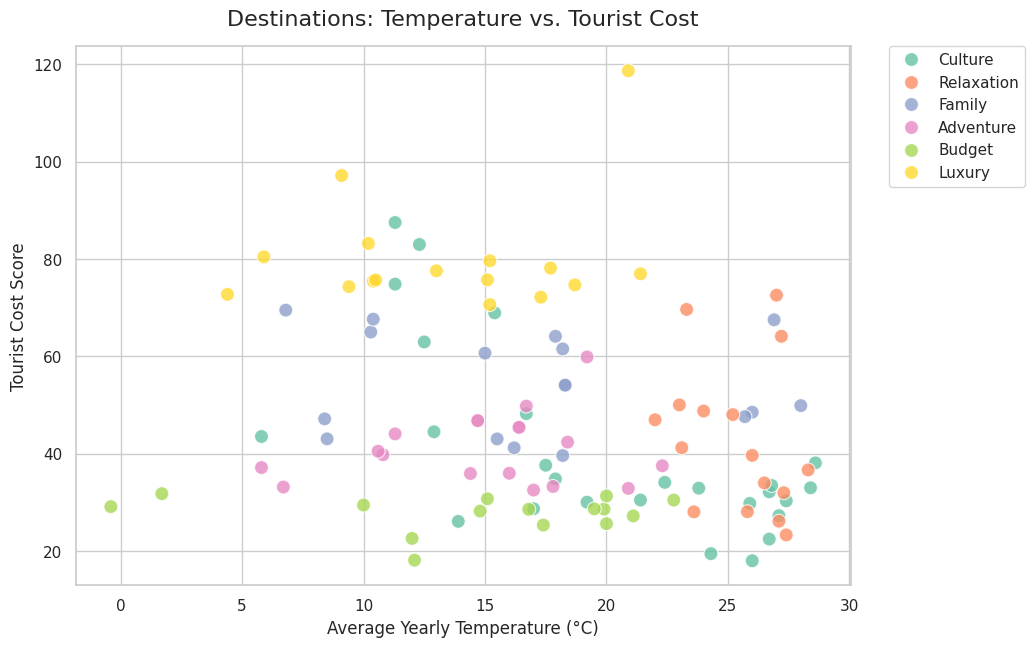

In [10]:
# Cell 8: Feature Scatter Plot

fig, ax = plt.subplots(figsize=(10, 7))

# Create a scatter plot
# We map Average Temperature to the X-axis, Cost to the Y-axis, and color by Travel_Style
sns.scatterplot(
    data=df, 
    x='Temp_YearAvg', 
    y='Tourist_Cost_Score', 
    hue='Travel_Style', 
    palette='Set2', # A nice distinct color palette
    s=100,          # Size of the dots
    alpha=0.8,      # Slight transparency to see overlapping dots
    ax=ax
)

# Add titles and labels
ax.set_title('Destinations: Temperature vs. Tourist Cost', fontsize=16, pad=15)
ax.set_xlabel('Average Yearly Temperature (°C)', fontsize=12)
ax.set_ylabel('Tourist Cost Score', fontsize=12)

# Move the legend outside the plot so it doesn't cover data points
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

# Save the plot to the EDA directory
scatter_plot_path = eda_dir / 'feature_scatter_plot.png'
plt.savefig(scatter_plot_path, bbox_inches='tight')

print(f"Successfully saved feature scatter plot to: {scatter_plot_path}")